In [1]:
import torch
import matplotlib.pyplot as plt


x = torch.tensor([0,1,2,3,4,5,6,7.])
y = torch.tensor([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])
m = torch.tensor([0.9])
b = torch.tensor([0.1])

def regression(my_m,my_x,my_b):
    return (my_m*my_x)+my_b
def mse(my_yhat,my_y):
    sigma = torch.sum((my_yhat-my_y)**2)
    return sigma/len(my_y)


y_hat = regression(m,x,b)
C = mse(y_hat,y)

### Math Explaination
C = sigma((yhat-y)**2)/n  
assuming u = yhat-y  
so C = sigma(u**2)/n  
  
del C / del yhat = del C /del u * del u /del yhat  

u = yhat - y  
del u /del yhat = 1  
  
so del C /del yhat = del C / del u  
  
del C /del yhat = 2/n*sigma(yhat-y)  

as we know yhat = m *x + b  
so ,  
del yhat / del m = x  
del yhat / del b = 1  

therefore ,  
del C /del m = del C / del yhat * del yhat / del m  
del C /del b = del C /del yhat * del yhat / del b  
so applying all above ,  
del C /del m = 2/n * sigma((yhat-y)*x)
del C / del b = 2/n * sigma(yhat-y)*1

In [2]:
def del_c_del_m(my_yhat,my_y,my_x):
    return (2/len(my_y))*torch.sum((my_yhat-my_y)*my_x)

In [3]:
def del_c_del_b(my_yhat,my_y):
    return (2/len(my_y))*torch.sum(my_yhat-my_y)

def update_params(my_m,my_b,my_mgrad,my_bgrad,learning_rate):
    return my_m-(learning_rate*my_mgrad),my_b-(learning_rate*my_bgrad)

In [4]:
def reg_plot(my_x,my_y,my_m,my_b,my_c,my_mgrad,my_bgrad,epoch,include_grad=True):
    title = 'Cost = {}, Epoch = {}'.format('%.3g' % my_c.item(),'%.3g' % epoch)
    if include_grad:
        xlabel = 'm = {}, m grad = {}'.format('%.3g' % my_m.item(), '%.3g' % my_mgrad.item())
        ylabel = 'b = {}, b grad = {}'.format('%.3g' % my_b.item(), '%.3g' % my_bgrad.item())
    else:
        xlabel = 'm = {}'.format('%.3g' % my_m.item())        
        ylabel = 'b = {}'.format('%.3g' % my_b.item())
    
    fig,ax = plt.subplots()
    
    ax.scatter(my_x,my_y)
    
    x_min,x_max = ax.get_xlim()
    y_min,y_max = my_m*x_min + my_b,my_m*x_max + my_b
    ax.set_xlim([x_min,x_max])
    ax.plot([x_min,x_max],[y_min.item(),y_max.item()])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

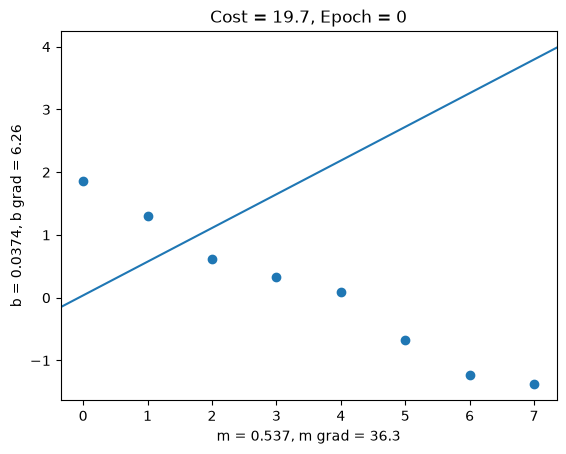

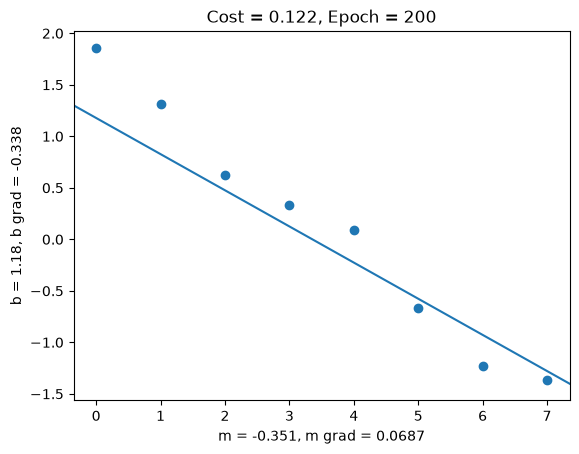

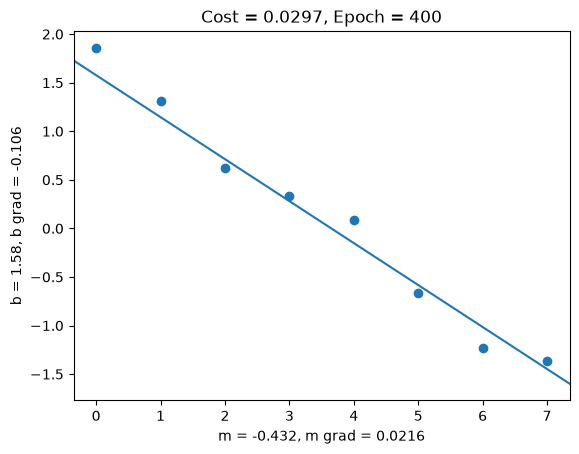

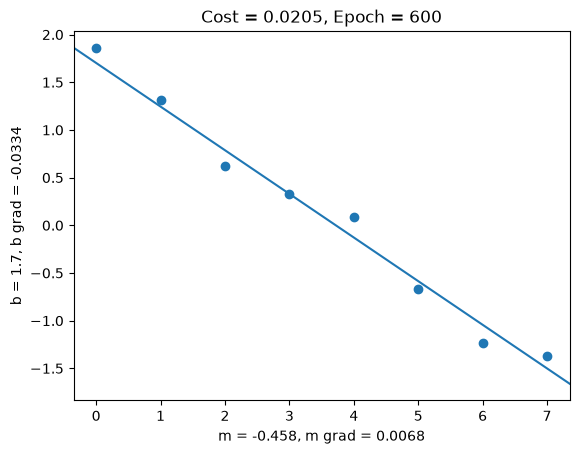

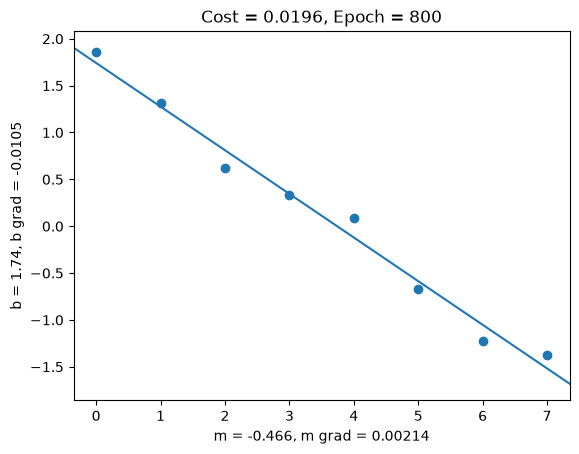

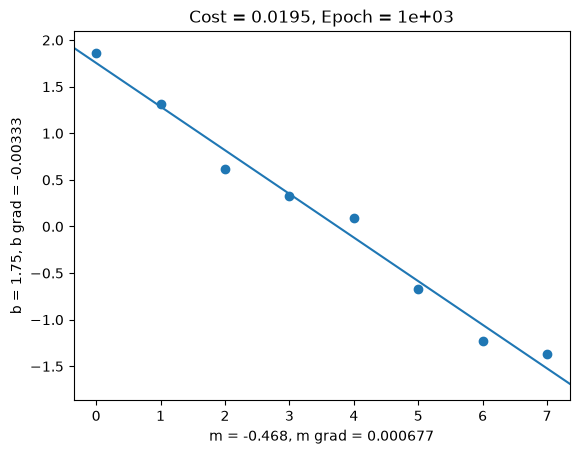

In [5]:
epochs = 1000
learning_rate = 0.01
for epoch in range(epochs):
    
    y_hat = regression(m,x,b)
    C = mse(y_hat,y)
    
    mgrad = del_c_del_m(y_hat,y,x)
    bgrad = del_c_del_b(y_hat,y)
    
    m,b = update_params(m,b,mgrad,bgrad,learning_rate)
    
    if epoch%200 ==0 :
        reg_plot(x,y,m,b,C,mgrad,bgrad,epoch)

reg_plot(x,y,m,b,C,mgrad,bgrad,1000)